# Extra research

https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html?

Thresholding in simple terms



In [32]:
#import libraries
import cv2
import numpy as np
import tensorflow as tf
from collections import Counter
import os
import matplotlib.pyplot as plt

# this is to remvoe teh warnings for my tf library version 2.10 this si needed wro when i utilze gpu
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

MODEL_PATH = "rice_classifier.keras"
IMAGE_PATH = "handful.jpg"
IMG_SIZE = 224
MIN_AREA = 100
CLASS_NAMES = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

In [33]:
# load my model in 
model = tf.keras.models.load_model(MODEL_PATH)
print(model)
model.summary()

<Sequential name=sequential_1, built=True>


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (64, 224, 224, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (64, 224, 224, 16)     │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (64, 112, 112, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (64, 112, 112, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (64, 56, 56, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (64, 56, 56, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (64, 28, 28, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (64, 50176)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (64, 128)              │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (64, 5)                │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,464,631 (24.66 MB)

 Trainable params: 6,464,629 (24.66 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [34]:
print(model.input_shape)
print(CLASS_NAMES)
print(len(CLASS_NAMES))
print(model.output_shape)

(64, 224, 224, 1)
['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
5
(64, 5)


In [35]:
img_path = "Sample_photos/rice_hand-3.jpg"

image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(f"Could not read image: {img_path}")
#we need to modify the image so we can keep the orignal for later wehn we apply the boxes themselves
original = image.copy()



# Thresholding 
documentation: https://docs.opencv.org/3.4/d7/d4d/tutorial_py_thresholding.html

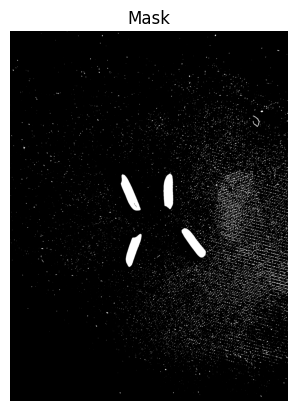

In [36]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

ret, mask = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)


white_ratio = np.mean(mask == 255)
if white_ratio > 69.0:
    mask = cv2.bitwise_not(mask)

plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()

# contours helps us find the bounding boxes like we learned in class
What are contours video:
https://www.youtube.com/watch?v=LMamYJYnws8

RETR_EXTERNAL is a contour retrieval mode used in OpenCV’s cv2.findContours() function that extracts only the extreme outer boundaries of objects in a binary image. It ignores any nested contours (holes or shapes inside another shape), making it a high-performance option when only the main outline of objects is needed

# Youtube video to help guide us on how to utilize cv2 find countours
https://www.youtube.com/watch?v=lBMosWq8NKo

In [37]:
contours, _ = cv2.findContours(
    mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE
)
results = []
#we need to estabisth the count for the number of rice grains
counts = Counter()

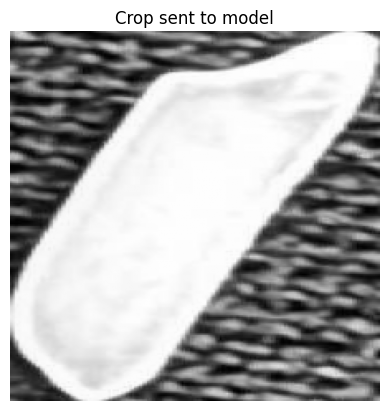

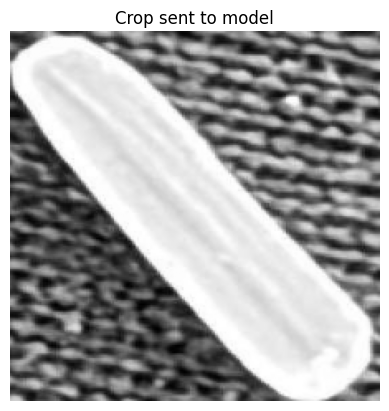

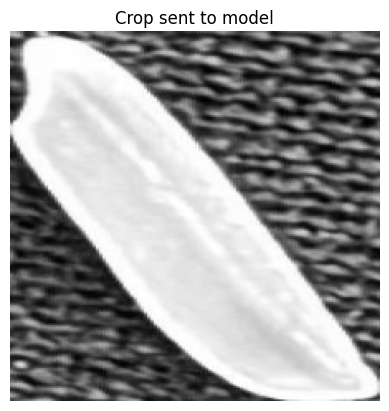

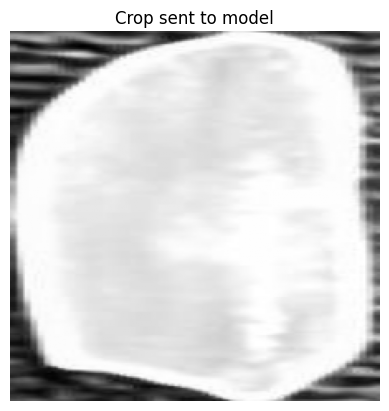

In [38]:
for contour in contours:
    area = cv2.contourArea(contour)
    smallest_acceptance = 2000
    if area < smallest_acceptance:
        continue

    x, y, w, h = cv2.boundingRect(contour)
    #create the boundry box itself 
    crop = original[y:y+h, x:x+w]
    # need to re grey scale the value
    crop_gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    # apply threshold again

    crop_resized = cv2.resize(crop_gray, (IMG_SIZE, IMG_SIZE))

    crop_resized = crop_resized.astype("float32") / 255.0
    plt.imshow(crop_resized, cmap="gray")
    plt.title("Crop sent to model")
    plt.axis("off")
    plt.show()
    
    x_input = np.expand_dims(crop_resized, axis=(0, -1))

    probs = model.predict(x_input,verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_label = CLASS_NAMES[pred_idx]
    confidence = float(probs[pred_idx])

    counts[pred_label] += 1
    results.append((x, y, w, h, pred_label, confidence))

    cv2.rectangle(original, (x, y), (x+w, y+h), (0, 255, 0), 2)


Counts:
{'Jasmine': 4}


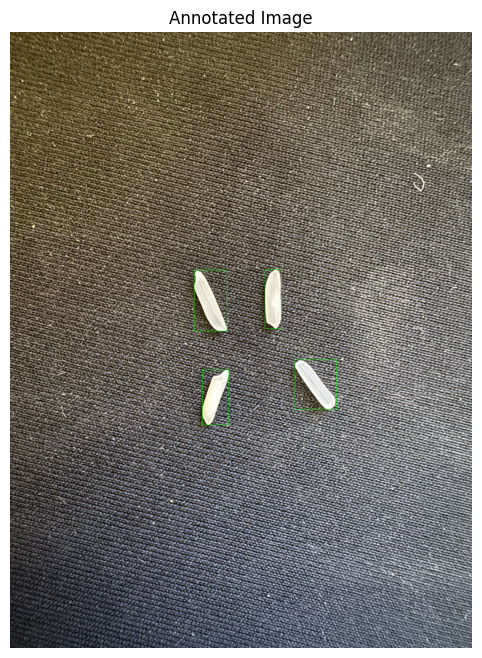

In [39]:
print("Counts:")
print(dict(counts))

cv2.imwrite("mask.png", mask)
cv2.imwrite("annotated.png", original)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Annotated Image")
plt.axis("off")
plt.show()